# Face Recognition Benchmark: Howdy (dlib) vs GhostFaceNet

Compares the facial recognition pipeline used by Howdy (dlib ResNet-based) against
GhostFaceNet ([HamadYA/GhostFaceNets](https://github.com/HamadYA/GhostFaceNets))
on the LFW (Labeled Faces in the Wild) verification benchmark.

**Metrics evaluated:** accuracy, false positive rate (FAR), false negative rate (FRR),
confusion matrix values, and ROC / AUC.

In [32]:
%pip install -q tensorflow scikit-learn matplotlib tqdm pandas dlib opencv-python face-recognition

Note: you may need to restart the kernel to use updated packages.


In [33]:
import sys
import numpy as np
import cv2
import dlib
import face_recognition_models
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm

print(f"TensorFlow {tf.__version__}")
print(f"dlib      {dlib.__version__}")
print(f"OpenCV    {cv2.__version__}")

TensorFlow 2.21.0
dlib      20.0.1
OpenCV    4.13.0


In [34]:
# Load LFW test pairs directly from the funneled images already on disk
# (downloaded by sklearn on a previous run — no re-download needed).
from pathlib import Path as _Path

_LFW_ROOT = _Path.home() / "scikit_learn_data" / "lfw_home"
_LFW_IMGS = _LFW_ROOT / "lfw_funneled"
_PAIRS_FILE = _LFW_ROOT / "pairsDevTest.txt"

pairs: list[tuple[str, str, int]] = []

with open(_PAIRS_FILE) as _f:
    _n = int(_f.readline().strip())
    # same-person pairs
    for _ in range(_n):
        _parts = _f.readline().split()
        _name, _n1, _n2 = _parts[0], int(_parts[1]), int(_parts[2])
        _p1 = str(_LFW_IMGS / _name / f"{_name}_{_n1:04d}.jpg")
        _p2 = str(_LFW_IMGS / _name / f"{_name}_{_n2:04d}.jpg")
        pairs.append((_p1, _p2, 1))
    # different-person pairs
    for _ in range(_n):
        _parts = _f.readline().split()
        _name1, _n1, _name2, _n2 = _parts[0], int(_parts[1]), _parts[2], int(_parts[3])
        _p1 = str(_LFW_IMGS / _name1 / f"{_name1}_{_n1:04d}.jpg")
        _p2 = str(_LFW_IMGS / _name2 / f"{_name2}_{_n2:04d}.jpg")
        pairs.append((_p1, _p2, 0))

same_count = sum(1 for *_, l in pairs if l == 1)
diff_count = sum(1 for *_, l in pairs if l == 0)
print(f"Loaded {len(pairs)} pairs from {_PAIRS_FILE}")
print(f"  Same-person (positive):      {same_count}")
print(f"  Different-person (negative): {diff_count}")
print(f"  Image directory:             {_LFW_IMGS}")

Loaded 1000 pairs from /home/carlos/scikit_learn_data/lfw_home/pairsDevTest.txt
  Same-person (positive):      500
  Different-person (negative): 500
  Image directory:             /home/carlos/scikit_learn_data/lfw_home/lfw_funneled


In [35]:
# Reference 5-point landmarks used in ArcFace / GhostFaceNet training
ARCFACE_REF = np.float32([
    [38.2946, 51.6963],
    [73.5318, 51.5014],
    [56.0252, 71.7366],
    [41.5493, 92.3655],
    [70.7299, 92.2041],
])


def align_face_112(image: np.ndarray, landmarks: list[tuple[int, int]]) -> np.ndarray:
    """Warp face region to 112x112 using a 5-point similarity transform."""
    src = np.float32(landmarks)
    transform, _ = cv2.estimateAffinePartial2D(src, ARCFACE_REF, method=cv2.RANSAC)
    if transform is None:
        return cv2.resize(image, (112, 112))
    return cv2.warpAffine(image, transform, (112, 112))


def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    a = a / (np.linalg.norm(a) + 1e-10)
    b = b / (np.linalg.norm(b) + 1e-10)
    return float(np.dot(a, b))


def l2_distance(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.linalg.norm(a - b))


def compute_metrics(scores: list[float], labels: list[int], threshold: float) -> dict:
    """Compute TP/FP/TN/FN and derived rates at a given decision threshold.

    Scores >= threshold are treated as 'same person' (positive prediction).
    """
    preds = (np.array(scores) >= threshold).astype(int)
    lab = np.array(labels)
    tp = int(np.sum((preds == 1) & (lab == 1)))
    fp = int(np.sum((preds == 1) & (lab == 0)))
    tn = int(np.sum((preds == 0) & (lab == 0)))
    fn = int(np.sum((preds == 0) & (lab == 1)))
    accuracy = (tp + tn) / len(lab)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0  # False Accept Rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0  # False Reject Rate
    return {"accuracy": accuracy, "fpr": fpr, "fnr": fnr,
            "tp": tp, "fp": fp, "tn": tn, "fn": fn}


def find_best_threshold(scores: list[float], labels: list[int]) -> tuple[float, float]:
    """Return (threshold, accuracy) that maximises accuracy over 200 candidate values."""
    thresholds = np.linspace(np.min(scores), np.max(scores), 200)
    best_acc, best_t = 0.0, thresholds[0]
    for t in thresholds:
        acc = compute_metrics(scores, labels, t)["accuracy"]
        if acc > best_acc:
            best_acc, best_t = acc, t
    return best_t, best_acc

In [36]:
HOG_DETECTOR = dlib.get_frontal_face_detector()
SHAPE_PREDICTOR = dlib.shape_predictor(
    face_recognition_models.pose_predictor_five_point_model_location()
)
FACE_ENCODER = dlib.face_recognition_model_v1(
    face_recognition_models.face_recognition_model_location()
)

print("Howdy (dlib) models loaded")
print("  Detector: HOG frontal face detector")
print("  Landmarks: shape_predictor_5_face_landmarks")
print("  Encoder:  dlib_face_recognition_resnet_model_v1 (128-d embeddings)")


def get_howdy_embedding(img_path: str) -> np.ndarray | None:
    """Extract 128-d face embedding using Howdy's dlib pipeline.

    Returns None when no face is detected.
    """
    img = cv2.imread(img_path)
    if img is None:
        return None
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    detections = HOG_DETECTOR(rgb, 1)
    if not detections:
        return None
    detection = max(detections, key=lambda d: d.width() * d.height())
    landmarks = SHAPE_PREDICTOR(rgb, detection)
    return np.array(FACE_ENCODER.compute_face_descriptor(rgb, landmarks, 1))

Howdy (dlib) models loaded
  Detector: HOG frontal face detector
  Landmarks: shape_predictor_5_face_landmarks
  Encoder:  dlib_face_recognition_resnet_model_v1 (128-d embeddings)


In [37]:
GHOSTFACENET_MODEL_PATH = Path("ghostfacenets") / "checkpoints" / "ghostnetv1_w1.3_s2.h5"

# Keras 2-saved models include a `groups` key in DepthwiseConv2D config that
# Keras 3 (TF >= 2.16) does not accept.  This shim drops that key on load.
class _DepthwiseConv2DCompat(tf.keras.layers.DepthwiseConv2D):
    @classmethod
    def from_config(cls, config):
        config.pop("groups", None)
        return super().from_config(config)

ghostfacenet_model = tf.keras.models.load_model(
    str(GHOSTFACENET_MODEL_PATH),
    compile=False,
    custom_objects={"DepthwiseConv2D": _DepthwiseConv2DCompat},
)
print("GhostFaceNet model loaded")
print(f"  Input shape:  {ghostfacenet_model.input_shape}")
print(f"  Output shape: {ghostfacenet_model.output_shape}")

# Resolve input tensor name once to avoid Keras 3 structure-mismatch warnings
_GFN_INPUT_KEY = ghostfacenet_model.inputs[0].name.split(":")[0]


def get_ghostfacenet_embedding(img_path: str) -> np.ndarray | None:
    """Extract L2-normalised 512-d embedding using GhostFaceNet.

    Aligns to 112x112 using the ArcFace similarity transform (align_face_112)
    with the 5 landmarks from dlib's shape predictor.  This avoids the
    dlib.get_face_chip centering that distorts ArcFace-expected proportions
    and prevents the double-crop zoom caused by re-detecting an already-funneled
    image with get_face_chip's internal padding.  Returns None when no face is
    detected or an unexpected error occurs.
    """
    img = cv2.imread(img_path)
    if img is None:
        return None
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    try:
        detections = HOG_DETECTOR(rgb, 1)
        if not detections:
            return None
        detection = max(detections, key=lambda d: d.width() * d.height())
        shape = SHAPE_PREDICTOR(rgb, detection)
        # Convert the 5 dlib landmark points to a plain list of (x, y) tuples
        # matching the order expected by ARCFACE_REF:
        #   0=left-eye  1=right-eye  2=nose  3=left-mouth  4=right-mouth
        landmarks_np = [(shape.part(i).x, shape.part(i).y) for i in range(5)]
        aligned = align_face_112(rgb, landmarks_np)
    except Exception:
        return None

    # ArcFace / GhostFaceNet standard pixel normalisation
    face_input = (np.float32(aligned) - 127.5) * 0.0078125
    face_input = np.expand_dims(face_input, axis=0)
    embedding = ghostfacenet_model({_GFN_INPUT_KEY: face_input}, training=False).numpy()[0]
    # L2 normalisation so cosine similarity == dot product
    return embedding / (np.linalg.norm(embedding) + 1e-10)


GhostFaceNet model loaded
  Input shape:  (None, 112, 112, 3)
  Output shape: (None, 512)


In [38]:
print(f"Extracting embeddings for {len(pairs)} pairs...")

howdy_scores: list[float] = []
ghost_scores: list[float] = []
eval_labels: list[int] = []
skipped = 0

for img1_path, img2_path, label in tqdm(pairs, desc="Pairs"):
    e1_h = get_howdy_embedding(img1_path)
    e2_h = get_howdy_embedding(img2_path)
    e1_g = get_ghostfacenet_embedding(img1_path)
    e2_g = get_ghostfacenet_embedding(img2_path)

    if any(e is None for e in (e1_h, e2_h, e1_g, e2_g)):
        skipped += 1
        continue

    # Howdy comparison: L2 distance (lower = more similar).
    # Negate so that higher score == more similar (consistent with GhostFaceNet).
    howdy_scores.append(-l2_distance(e1_h, e2_h))

    # GhostFaceNet comparison: cosine similarity (higher = more similar).
    ghost_scores.append(cosine_similarity(e1_g, e2_g))

    eval_labels.append(label)

print(f"\nProcessed: {len(eval_labels)} pairs  |  Skipped (no face detected): {skipped}")
print(f"  Same-person (positive):      {sum(eval_labels)}")
print(f"  Different-person (negative): {len(eval_labels) - sum(eval_labels)}")

Extracting embeddings for 1000 pairs...


Pairs: 100%|██████████| 1000/1000 [20:36<00:00,  1.24s/it]


Processed: 994 pairs  |  Skipped (no face detected): 6
  Same-person (positive):      497
  Different-person (negative): 497


In [39]:
howdy_threshold, _ = find_best_threshold(howdy_scores, eval_labels)
ghost_threshold, _ = find_best_threshold(ghost_scores, eval_labels)

howdy_m = compute_metrics(howdy_scores, eval_labels, howdy_threshold)
ghost_m = compute_metrics(ghost_scores, eval_labels, ghost_threshold)

rows = [
    ("Accuracy",             "accuracy", ".4f"),
    ("False Positive Rate",  "fpr",      ".4f"),
    ("False Negative Rate",  "fnr",      ".4f"),
    ("True Positives (TP)",  "tp",       "d"),
    ("False Positives (FP)", "fp",       "d"),
    ("True Negatives (TN)",  "tn",       "d"),
    ("False Negatives (FN)", "fn",       "d"),
]

print(f"{'Metric':<26} {'Howdy / dlib':>13} {'GhostFaceNet':>14}")
print("-" * 55)
for label_str, key, fmt in rows:
    h = format(howdy_m[key], fmt)
    g = format(ghost_m[key], fmt)
    print(f"{label_str:<26} {h:>13}  {g:>13}")
print("-" * 55)
print(f"Optimal threshold          {howdy_threshold:>13.4f}  {ghost_threshold:>13.4f}")

Metric                      Howdy / dlib   GhostFaceNet
-------------------------------------------------------
Accuracy                          0.9869         0.6247
False Positive Rate               0.0080         0.3481
False Negative Rate               0.0181         0.4024
True Positives (TP)                  488            297
False Positives (FP)                   4            173
True Negatives (TN)                  493            324
False Negatives (FN)                   9            200
-------------------------------------------------------
Optimal threshold                -0.6058         0.5248


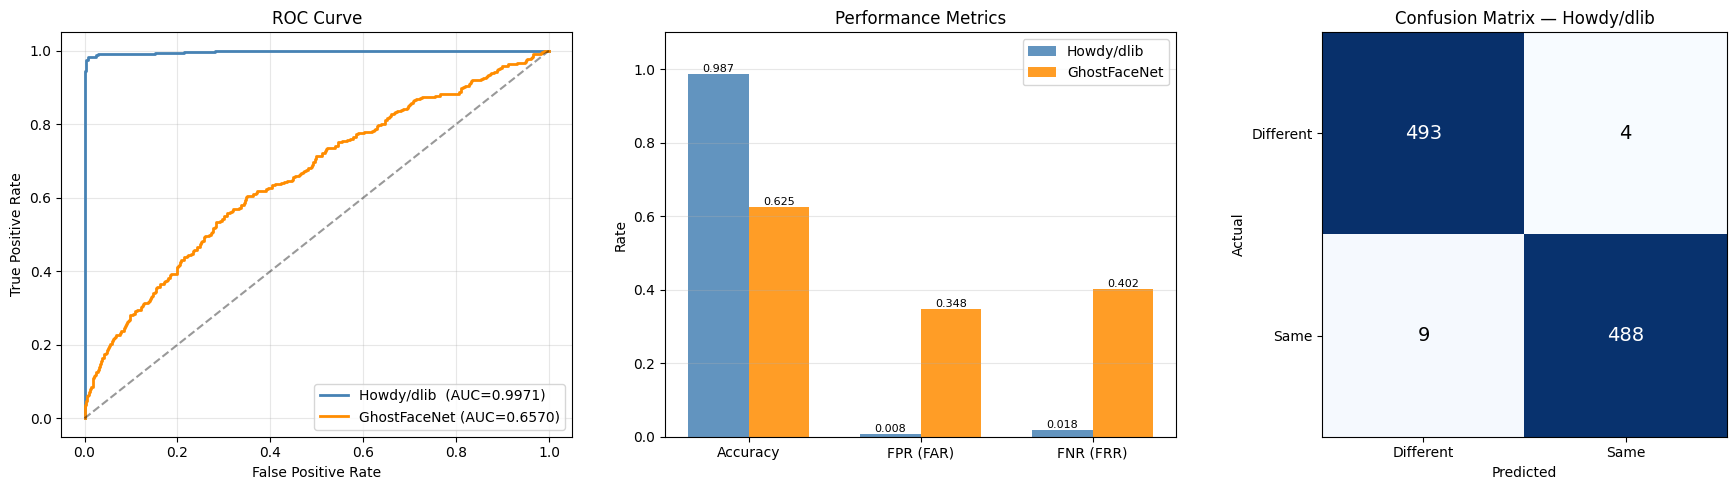


Howdy/dlib AUC:    0.9971
GhostFaceNet AUC:  0.6570


In [40]:
fpr_h, tpr_h, _ = roc_curve(eval_labels, howdy_scores)
fpr_g, tpr_g, _ = roc_curve(eval_labels, ghost_scores)
auc_h = auc(fpr_h, tpr_h)
auc_g = auc(fpr_g, tpr_g)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- ROC curve ---
axes[0].plot(fpr_h, tpr_h, label=f"Howdy/dlib  (AUC={auc_h:.4f})", color="steelblue", lw=2)
axes[0].plot(fpr_g, tpr_g, label=f"GhostFaceNet (AUC={auc_g:.4f})", color="darkorange", lw=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Accuracy / FPR / FNR bar chart ---
metric_keys = ["accuracy", "fpr", "fnr"]
metric_labels = ["Accuracy", "FPR (FAR)", "FNR (FRR)"]
x = np.arange(len(metric_labels))
w = 0.35
hv = [howdy_m[k] for k in metric_keys]
gv = [ghost_m[k] for k in metric_keys]
b1 = axes[1].bar(x - w / 2, hv, w, label="Howdy/dlib",   color="steelblue", alpha=0.85)
b2 = axes[1].bar(x + w / 2, gv, w, label="GhostFaceNet", color="darkorange", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_labels)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("Rate")
axes[1].set_title("Performance Metrics")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)
for bar in list(b1) + list(b2):
    axes[1].annotate(
        f"{bar.get_height():.3f}",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", fontsize=8,
    )

# --- Confusion matrix side-by-side ---
for ax, m, name, color in [
    (axes[2], howdy_m, "Howdy/dlib", "Blues"),
]:
    cm = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]])
    im = ax.imshow(cm, interpolation="nearest", cmap=color)
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Different", "Same"])
    ax.set_yticklabels(["Different", "Same"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)

plt.tight_layout()
plt.savefig("face_recognition_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nHowdy/dlib AUC:    {auc_h:.4f}")
print(f"GhostFaceNet AUC:  {auc_g:.4f}")

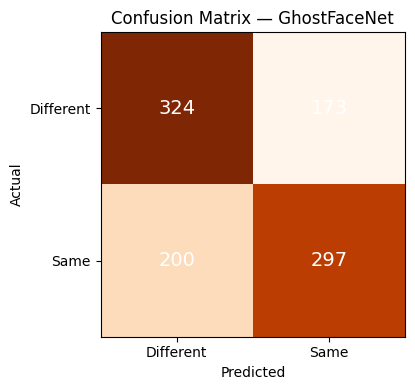

In [41]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = np.array([[ghost_m["tn"], ghost_m["fp"]], [ghost_m["fn"], ghost_m["tp"]]])
ax.imshow(cm, interpolation="nearest", cmap="Oranges")
ax.set_title("Confusion Matrix — GhostFaceNet")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Different", "Same"])
ax.set_yticklabels(["Different", "Same"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.tight_layout()
plt.show()